In [1]:
#All the imports
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import norm
from scipy.stats import kurtosis
from scipy.ndimage import maximum_filter, label
import multiprocessing as mp
import os

In [2]:
#Function Definitions
def partial_x_2d(f,dx):
    """Compute ∂f/∂x using 2nd-order central differences with periodic BCs."""
    Nx, Ny = f.shape
    df_dx = np.zeros_like(f)
    
    # Central difference in x-direction (axis=0)
    df_dx[1:Nx-1, :] = (f[2:Nx, :] - f[0:Nx-2, :]) / (2 * dx)
    
    # Periodic boundaries (x-direction)
    df_dx[0, :] = (f[1, :] - f[-1, :]) / (2 * dx)
    df_dx[-1, :] = (f[0, :] - f[-2, :]) / (2 * dx)
    
    return df_dx

def partial_y_2d(f,dy):
    """Compute ∂f/∂y using 2nd-order central differences with periodic BCs."""
    Nx, Ny = f.shape
    df_dy = np.zeros_like(f)
    
    # Central difference in y-direction (axis=1)
    df_dy[:, 1:Ny-1] = (f[:, 2:Ny] - f[:, 0:Ny-2]) / (2 * dy)
    
    # Periodic boundaries (y-direction)
    df_dy[:, 0] = (f[:, 1] - f[:, -1]) / (2 * dy)
    df_dy[:, -1] = (f[:, 0] - f[:, -2]) / (2 * dy)
    
    return df_dy

def partial_x_fft(f, dx):
    """
    Calculate ∂f/∂x using FFT on a 2D grid.

    Parameters:
        f (2D np.array): Function values on a 2D grid (shape: Nx × Ny).
        dx (float): Grid spacing in the x-direction.

    Returns:
        df_dx (2D np.array): Partial derivative ∂f/∂x.
    """
    nx, ny = f.shape
    kx = np.fft.fftfreq(nx, d=dx) * 2 * np.pi  # Wavenumbers in x
    kx = kx[:, np.newaxis]                     # Make it 2D for broadcasting

    f_hat = np.fft.fft2(f)
    df_dx_hat = 1j * kx * f_hat
    df_dx = np.fft.ifft2(df_dx_hat).real

    return np.array(df_dx)

def partial_y_fft(f, dy):
    """
    Calculate ∂f/∂y using FFT on a 2D grid.

    Parameters:
        f (2D np.array): Function values on a 2D grid (shape: Nx × Ny).
        dy (float): Grid spacing in the y-direction.

    Returns:
        df_dy (2D np.array): Partial derivative ∂f/∂y.
    """
    nx, ny = f.shape
    ky = np.fft.fftfreq(ny, d=dy) * 2 * np.pi  # Wavenumbers in y
    ky = ky[np.newaxis, :]                     # Make it 2D for broadcasting

    f_hat = np.fft.fft2(f)
    df_dy_hat = 1j * ky * f_hat
    df_dy = np.fft.ifft2(df_dy_hat).real

    return df_dy

def index_of_just_smaller(arr, value):
    arr = np.asarray(arr)
    mask = arr < value
    if not np.any(mask):
        return None  # No smaller value exists
    return np.argmax(np.where(mask, arr, -np.inf))

In [3]:
# List of simulation directories
sim_dirs = [
    '/DATA/DEVESH/ExtremeBetaSimulations/0.0625/'
]

dx = 0.0625
dy = 0.0625

In [5]:
def process_sim_dir(sim_dir):
    J_rms = []
    for i in range(0, 300):
        print(f"{sim_dir}: i = {i}", flush=True)
        
        File_Bx = f'{sim_dir}/Bx_ApJ_t{i}.h5'
        File_By = f'{sim_dir}/By_ApJ_t{i}.h5'

        with h5py.File(File_Bx, 'r') as fBx, h5py.File(File_By, 'r') as fBy:
            data_Bx = fBx['DS1'][:].T
            data_By = fBy['DS1'][:].T

        J_par_FT = partial_x_fft(data_By, dx) - partial_y_fft(data_Bx, dy)
        rms = np.sqrt(np.mean(J_par_FT**2))
        J_rms.append(rms)

    return sim_dir, J_rms


if __name__ == "__main__":
    with mp.Pool(processes=8) as pool:   # adjust to number of CPU cores
        results = pool.map(process_sim_dir, sim_dirs)

    all_J_rms = {sim_dir: J_rms for sim_dir, J_rms in results}

/DATA/DEVESH/ExtremeBetaSimulations/0.0625/: i = 0
/DATA/DEVESH/ExtremeBetaSimulations/0.0625/: i = 1
/DATA/DEVESH/ExtremeBetaSimulations/0.0625/: i = 2
/DATA/DEVESH/ExtremeBetaSimulations/0.0625/: i = 3
/DATA/DEVESH/ExtremeBetaSimulations/0.0625/: i = 4
/DATA/DEVESH/ExtremeBetaSimulations/0.0625/: i = 5
/DATA/DEVESH/ExtremeBetaSimulations/0.0625/: i = 6
/DATA/DEVESH/ExtremeBetaSimulations/0.0625/: i = 7
/DATA/DEVESH/ExtremeBetaSimulations/0.0625/: i = 8
/DATA/DEVESH/ExtremeBetaSimulations/0.0625/: i = 9
/DATA/DEVESH/ExtremeBetaSimulations/0.0625/: i = 10
/DATA/DEVESH/ExtremeBetaSimulations/0.0625/: i = 11
/DATA/DEVESH/ExtremeBetaSimulations/0.0625/: i = 12
/DATA/DEVESH/ExtremeBetaSimulations/0.0625/: i = 13
/DATA/DEVESH/ExtremeBetaSimulations/0.0625/: i = 14
/DATA/DEVESH/ExtremeBetaSimulations/0.0625/: i = 15
/DATA/DEVESH/ExtremeBetaSimulations/0.0625/: i = 16
/DATA/DEVESH/ExtremeBetaSimulations/0.0625/: i = 17
/DATA/DEVESH/ExtremeBetaSimulations/0.0625/: i = 18
/DATA/DEVESH/ExtremeBe

In [9]:
def process_sim_dir(sim_dir):
    B_rms = []
    for i in range(0, 300):
        File_Bx = f'{sim_dir}/Bx_ApJ_t{i}.h5'
        File_By = f'{sim_dir}/By_ApJ_t{i}.h5'

        with h5py.File(File_Bx, 'r') as fBx, h5py.File(File_By, 'r') as fBy:
            data_Bx = fBx['DS1'][:].T
            data_By = fBy['DS1'][:].T

        data_Bp = np.sqrt(data_Bx**2 + data_By**2)
        Bp_rms = np.sqrt(np.mean(data_Bp**2))
        B_rms.append(Bp_rms)

    return sim_dir, B_rms


if __name__ == "__main__":
    with mp.Pool(processes=8) as pool:   # adjust to number of CPU cores
        results = pool.map(process_sim_dir, sim_dirs)

    all_B_rms = {sim_dir: B_rms for sim_dir, B_rms in results}

/tmp/ipykernel_155072/831939213.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


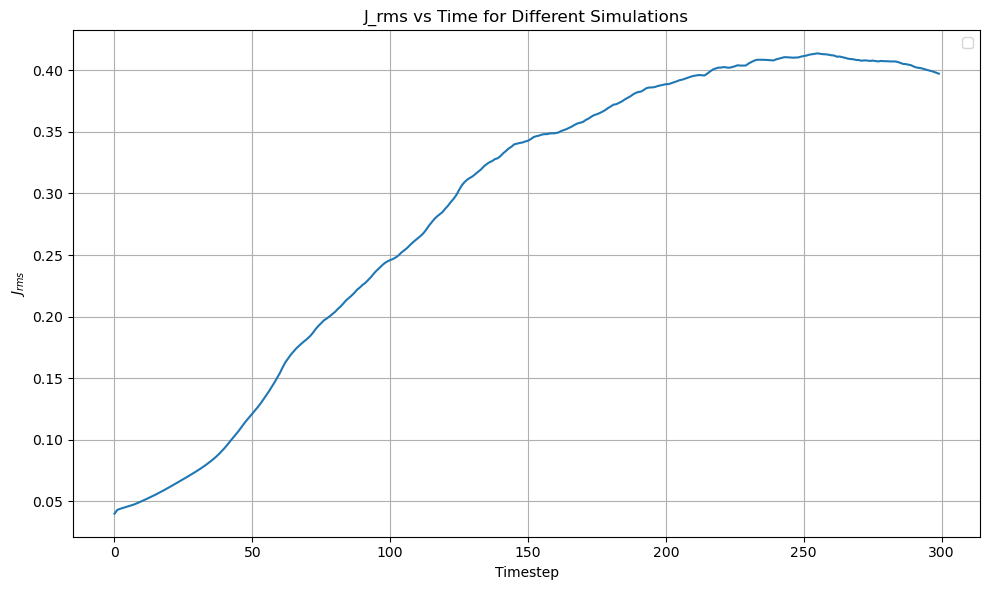

In [6]:
timesteps = np.arange(0, 300)

plt.figure(figsize=(10, 6))

for sim_dir, J_rms in all_J_rms.items():
    # Plot J_rms vs time for each simulation
    plt.plot(timesteps, J_rms, label=sim_dir.split('/')[-1])  # using last folder name as label

plt.xlabel('Timestep')
plt.ylabel(r'$J_{rms}$')
plt.title('J_rms vs Time for Different Simulations')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Jrms.png", dpi=300)
plt.show()

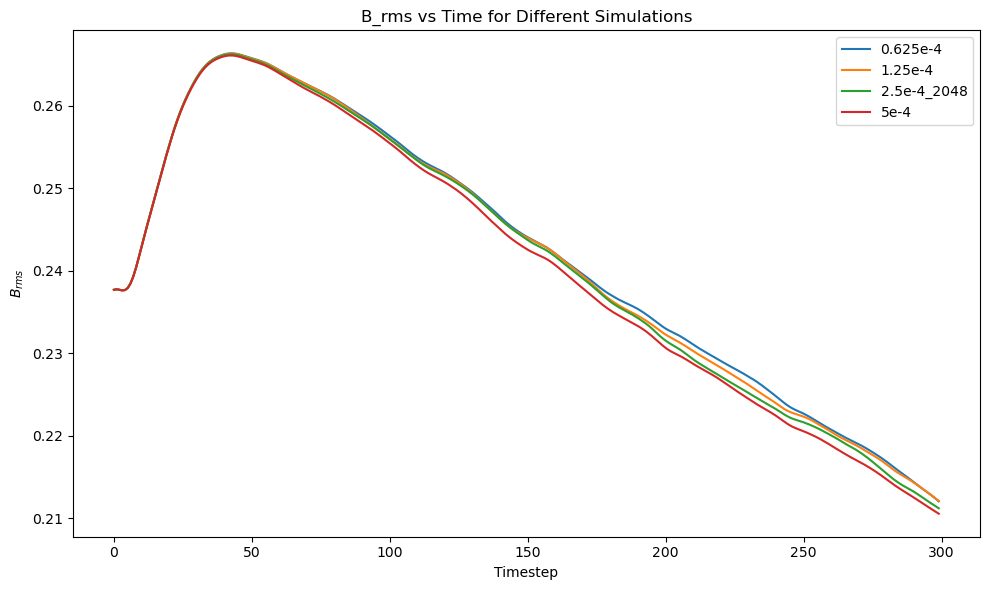

In [12]:
timesteps = np.arange(0, 300)

plt.figure(figsize=(10, 6))

for sim_dir, B_rms in all_B_rms.items():
    # Plot J_rms vs time for each simulation
    plt.plot(timesteps, B_rms, label=sim_dir.split('/')[-1])  # using last folder name as label

plt.xlabel('Timestep')
plt.ylabel(r'$B_{rms}$')
plt.title('B_rms vs Time for Different Simulations')
plt.legend()
# plt.grid(True)
plt.tight_layout()
plt.savefig("Brms.png", dpi=300)
plt.show()

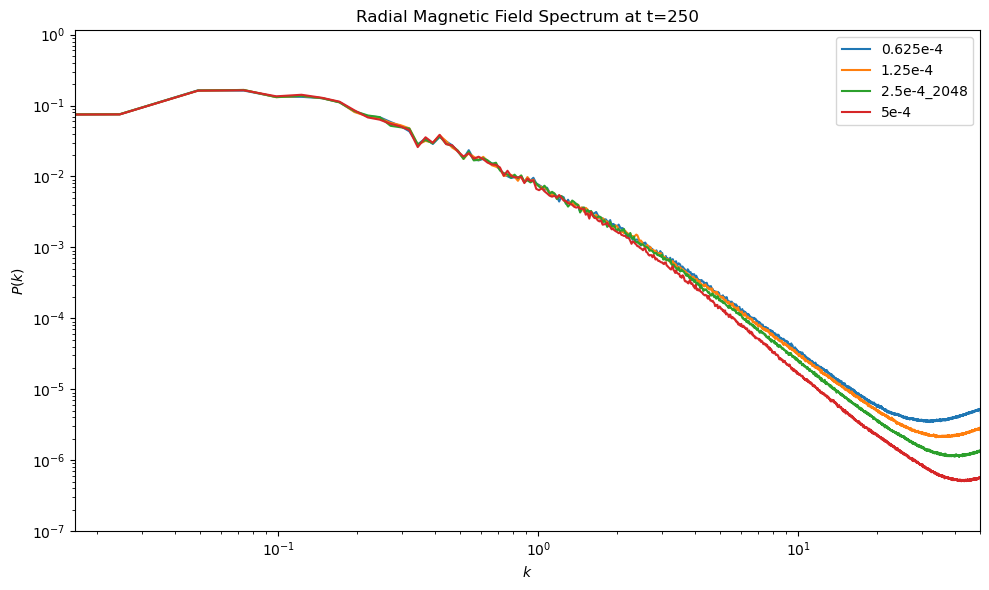

In [6]:
timestep = 250  # example timestep

plt.figure(figsize=(10, 6))

for sim_dir in sim_dirs:
    File_Bx = f'{sim_dir}/Bx_ApJ_t{timestep}.h5'
    File_By = f'{sim_dir}/By_ApJ_t{timestep}.h5'
    
    with h5py.File(File_Bx, 'r') as fBx, h5py.File(File_By, 'r') as fBy:
        data_Bx = fBx['DS1'][:]
        data_By = fBy['DS1'][:]
    
    # Compute radial spectra
    spectrum_Bx = compute_radial_spectrum(data_Bx, dx, dy)
    spectrum_By = compute_radial_spectrum(data_By, dx, dy)
    
    spectrum_Bp = np.recarray(spectrum_Bx.shape, dtype=spectrum_Bx.dtype)
    spectrum_Bp.kk = spectrum_Bx.kk
    spectrum_Bp.sp = spectrum_Bx.sp + spectrum_By.sp
    
    # Plot
    plt.loglog(spectrum_Bp.kk, spectrum_Bp.sp, label=sim_dir.split('/')[-1])

plt.xlabel(r'$k$')
plt.ylabel(r'$P(k)$')
plt.title(f'Radial Magnetic Field Spectrum at t={timestep}')
plt.legend()
# plt.grid(True, which='both', ls='--', lw=0.5)
plt.xlim(None, 50)
plt.ylim(1e-7, None)
plt.tight_layout()
plt.savefig("CompareBp_AllSimulations.png", dpi=300)
plt.show()

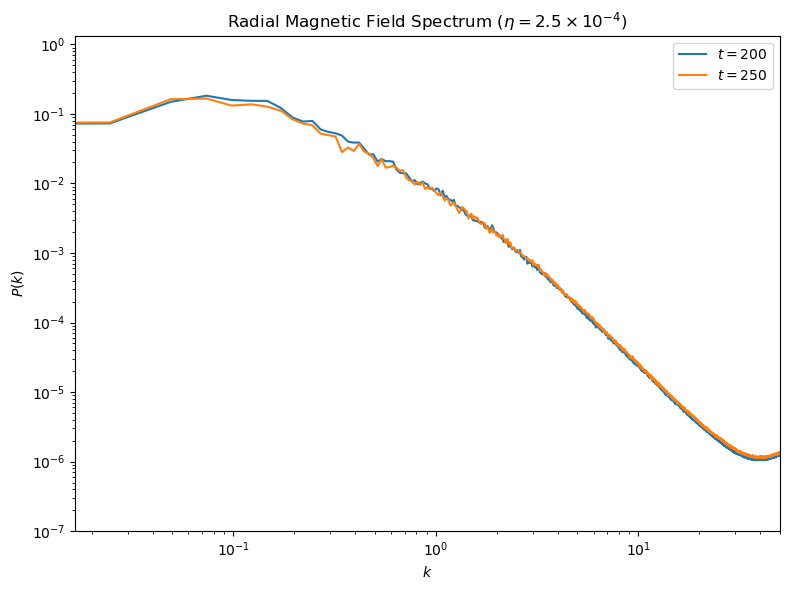

In [13]:
# Plotting Power Spectrum at t=200 and t=250 for resistivity of 2.5e-4

timesteps = [200, 250]

plt.figure(figsize=(8, 6))

for timestep in timesteps:
    File_Bx = f'/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Bx_ApJ_t{timestep}.h5'
    File_By = f'/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/By_ApJ_t{timestep}.h5'

    with h5py.File(File_Bx, 'r') as fBx, h5py.File(File_By, 'r') as fBy:
        data_Bx = fBx['DS1'][:]
        data_By = fBy['DS1'][:]

    # Compute radial spectra
    spectrum_Bx = compute_radial_spectrum(data_Bx, dx, dy)
    spectrum_By = compute_radial_spectrum(data_By, dx, dy)

    # Total perpendicular magnetic spectrum
    spectrum_Bp = np.recarray(
        spectrum_Bx.shape, dtype=spectrum_Bx.dtype
    )
    spectrum_Bp.kk = spectrum_Bx.kk
    spectrum_Bp.sp = spectrum_Bx.sp + spectrum_By.sp

    # Plot
    plt.loglog(
        spectrum_Bp.kk,
        spectrum_Bp.sp,
        label=fr"$t={timestep}$"
    )

plt.xlabel(r"$k$")
plt.ylabel(r"$P(k)$")
plt.title(r"Radial Magnetic Field Spectrum ($\eta=2.5\times10^{-4}$)")
plt.legend()
plt.xlim(None, 50)
plt.ylim(1e-7, None)
plt.tight_layout()
plt.savefig("CompareBp_TwoTimes.png", dpi=300)
plt.show()

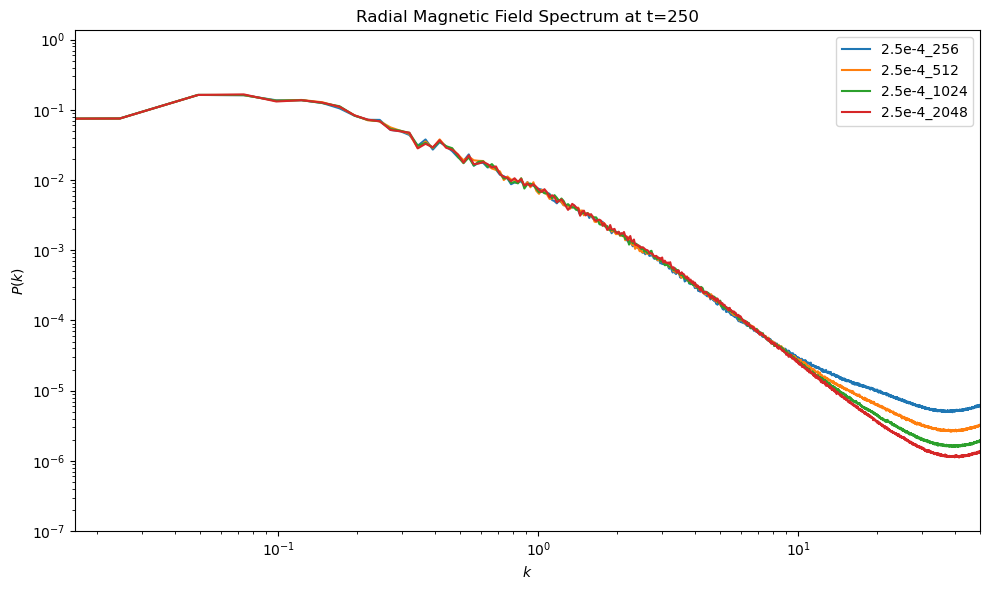

In [15]:
# List of simulation directories
sim_dirs = [
    '/DATA/DEVESH/ResistivityCheck/2.5e-4_256',
    '/DATA/DEVESH/ResistivityCheck/2.5e-4_512',
    '/DATA/DEVESH/ResistivityCheck/2.5e-4_1024',
    '/DATA/DEVESH/ResistivityCheck/2.5e-4_2048'
]

dx = 0.0625
dy = 0.0625

timestep = 250  # example timestep

plt.figure(figsize=(10, 6))

for sim_dir in sim_dirs:
    File_Bx = f'{sim_dir}/Bx_ApJ_t{timestep}.h5'
    File_By = f'{sim_dir}/By_ApJ_t{timestep}.h5'
    
    with h5py.File(File_Bx, 'r') as fBx, h5py.File(File_By, 'r') as fBy:
        data_Bx = fBx['DS1'][:]
        data_By = fBy['DS1'][:]
    
    # Compute radial spectra
    spectrum_Bx = compute_radial_spectrum(data_Bx, dx, dy)
    spectrum_By = compute_radial_spectrum(data_By, dx, dy)
    
    spectrum_Bp = np.recarray(spectrum_Bx.shape, dtype=spectrum_Bx.dtype)
    spectrum_Bp.kk = spectrum_Bx.kk
    spectrum_Bp.sp = spectrum_Bx.sp + spectrum_By.sp
    
    # Plot
    plt.loglog(spectrum_Bp.kk, spectrum_Bp.sp, label=sim_dir.split('/')[-1])

plt.xlabel(r'$k$')
plt.ylabel(r'$P(k)$')
plt.title(f'Radial Magnetic Field Spectrum at t={timestep}')
plt.legend()
# plt.grid(True, which='both', ls='--', lw=0.5)
plt.xlim(None, 50)
plt.ylim(1e-7, None)
plt.tight_layout()
plt.savefig("CompareBp_Differentppc.png", dpi=300)
plt.show()